In [114]:
import numpy as np 
import matplotlib.pyplot as plt

In [115]:
x=np.array([[1,7,9],
            [2,6,11]])
y=np.array([[16],
            [22]])

In [116]:
theta=np.zeros((x.shape[1],1))
alpha=0.01
num_iters=100

In [117]:
x

array([[ 1,  7,  9],
       [ 2,  6, 11]])

In [118]:
y

array([[16],
       [22]])

In [119]:
# ---- Hypothesis ----
def predict(x, theta):
    return np.dot(x, theta)

In [120]:
# ---- Cost Function ----
def cost_function(x, y, theta):
    m = len(y)
    predictions = predict(x, theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

In [121]:
def gradients(x, y, theta):
    m = len(y)
    return (1 / m) * np.dot(x.T, (predict(x, theta) - y))  # (n,m)·(m,1) → (n,1)


In [122]:
# ---- Gradient Descent ----
def gradient_descent(x, y, theta, alpha, num_iters):
    J_history = []
    for i in range(num_iters):
        theta = theta - alpha * gradients(x, y, theta)
        J_history.append(cost_function(x, y, theta))
    return theta, J_history


In [ ]:
# def stochastic_gradient_descent(x, y, theta, alpha, num_iters):
#     m=len(y)
#     j_history = []
#     for i in range(num_iters):
#         for j in range(m):
#             xi=x[j,:].reshape(1,x.shape[1])  # (1,n)
#             yi=y[j].reshape(1,1)
#             theta=theta-alpha*gradients(xi,yi,theta)
#             j_history.append(cost_function(x,y,theta))
#     return theta,j_history

In [ ]:
# theta,j_history=stochastic_gradient_descent(x,y,theta,alpha,num_iters)
# print(theta)
# print(j_history[-1],'final_cost')

[[ 0.96242619]
 [-0.66306294]
 [ 2.18679523]]
1.5212802499002685e-06 final_cost


In [ ]:
theta,j_history=gradient_descent(x,y,theta,alpha,num_iters)
print(theta)
print(j_history[-1],'final_cost')

[[ 0.93568143]
 [-0.60987942]
 [ 2.15643962]]
0.0025117538789065958 final_cost


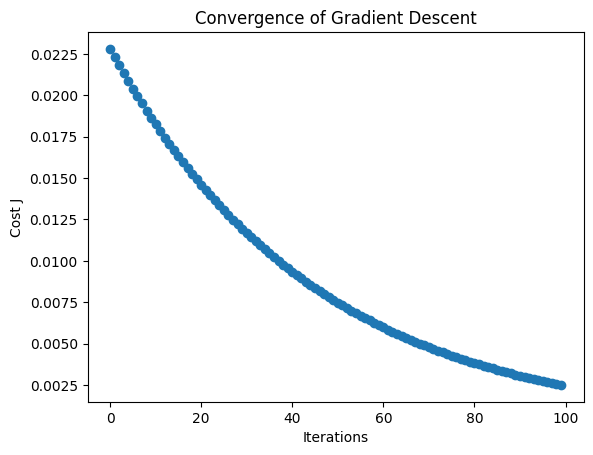

In [ ]:
plt.scatter(range(len(j_history)),j_history)
plt.xlabel('Iterations')
plt.ylabel('Cost J')
plt.title('Convergence of Gradient Descent')
plt.show()

In [ ]:
x_new=np.array([[20,25,30]])
y_pred=predict(x_new,theta)
print(y_pred)  # Output the predicted value
print(theta)

[[68.15983159]]
[[ 0.93568143]
 [-0.60987942]
 [ 2.15643962]]


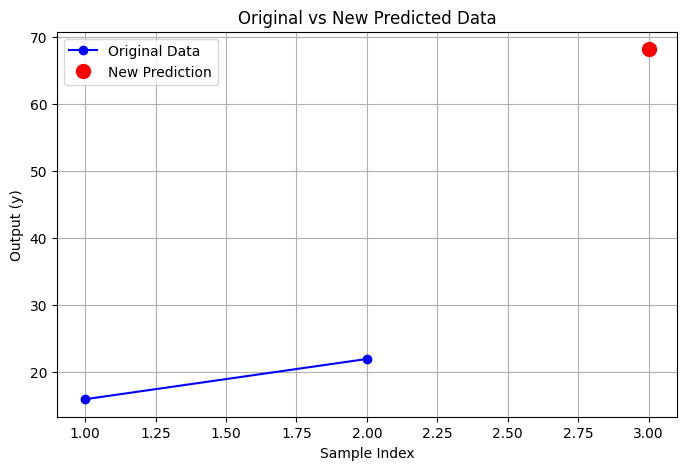

In [ ]:
x_indices = np.arange(1, len(y) + 2)  # [1, 2, 3]
y_all = np.vstack((y, y_pred))    # combine y and new prediction

# ---- Plot ----
plt.figure(figsize=(8,5))
plt.plot(x_indices[:-1], y, 'bo-', label='Original Data')     # original points
plt.plot(x_indices[-1], y_pred, 'ro', label='New Prediction', markersize=10)
plt.title('Original vs New Predicted Data')
plt.xlabel('Sample Index')
plt.ylabel('Output (y)')
plt.legend()
plt.grid(True)
plt.show()

voctorize form of a code

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
x=np.array([[1,3],[5,9]])
y=np.array([7,11])

In [4]:
x

array([[1, 3],
       [5, 9]])

In [5]:
y

array([ 7, 11])

In [7]:
# the add to bais term for a better result
x=np.hstack((np.ones((x.shape[0],1)),x))

In [8]:
x

array([[1., 1., 3.],
       [1., 5., 9.]])

In [9]:
def normal_equation(x,y):
    theta=np.linalg.inv(x.T@x)@x.T@y
    return theta